# Week 11

For Week 11, include concepts such as density-based spatial clustering of applications with noise (DBSCAN), hierarchical agglomerative clustering (HAC), linkage methods in HAC, and dendrograms. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [157]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import gower

In [158]:
random_state = 42

## ECC

### Import Dataset

In [24]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [25]:
# Identify all float64 columns
float64_cols = df.select_dtypes(include=['float64']).columns

# Convert only those columns to float32
df[float64_cols] = df[float64_cols].astype('float32')

In [26]:
df.dtypes

Time      float32
V1        float32
V2        float32
V3        float32
V4        float32
V5        float32
V6        float32
V7        float32
V8        float32
V9        float32
V10       float32
V11       float32
V12       float32
V13       float32
V14       float32
V15       float32
V16       float32
V17       float32
V18       float32
V19       float32
V20       float32
V21       float32
V22       float32
V23       float32
V24       float32
V25       float32
V26       float32
V27       float32
V28       float32
Amount    float32
Class       int64
dtype: object

In [27]:
X = df.drop(columns='Class')
y = df['Class']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 284315, 1: 492})
Resampled dataset shape: Counter({0: 49200, 1: 492})


### Scaling

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [9]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

60

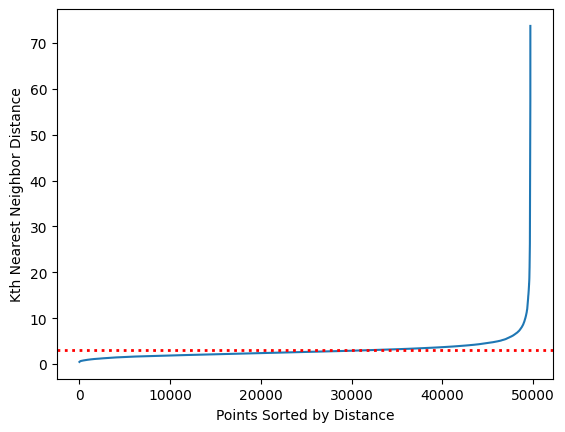

In [ ]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.axhline(y=5.5, linestyle=':', color='red', linewidth=2)
None

In [10]:
eps = 5.5 # Based on the curve, 5.5 looks to be where the elbow is

In [11]:
clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)

In [12]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 1
Estimated number of noise points: 1392


In [13]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [14]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [15]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [16]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 49692
Global Positive Rate: 0.0017
Number of Clusters (excluding noise): 1


In [17]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      -1          1392             407       0.292385
       0         48300              85       0.001760


In [18]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
       0         48300              85        0.00176


In [21]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the noise cluster to profile its characteristics
target_cluster_id = high_purity_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER -1.0 ---
        Cluster Mean   Global Mean  Difference
Time       -0.087586 -6.448414e-09   -0.087586
V1         -3.023728  0.000000e+00   -3.023728
V2         -0.185136  0.000000e+00   -0.185136
V3         -2.211241  7.369616e-09   -2.211241
V4          1.371175 -2.456539e-09    1.371175
V5         -0.829476 -4.913077e-09   -0.829476
V6         -0.160092  4.913077e-09   -0.160092
V7         -1.718079 -2.456539e-09   -1.718079
V8         -1.159784 -1.228269e-09   -1.159784
V9         -0.175413  2.456539e-09   -0.175413
V10        -0.833612 -4.913077e-09   -0.833612
V11         1.287629 -1.228269e-08    1.287629
V12        -1.592597  0.000000e+00   -1.592597
V13         0.065169 -4.068642e-09    0.065169
V14        -1.955331  0.000000e+00   -1.955331
V15         0.121434 -1.136149e-08    0.121434
V16        -1.306952  4.913077e-09   -1.306952
V17        -1.852792  9.826154e-09   -1.852792
V18        -0.960617 -2.456539e-09   -0.960617
V19       

In [22]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER -1.0 ---
|--- V1 <= -2.40
|   |--- V1 <= -3.47
|   |   |--- V14 <= 1.85
|   |   |   |--- class: 1
|   |   |--- V14 >  1.85
|   |   |   |--- class: 1
|   |--- V1 >  -3.47
|   |   |--- V8 <= 0.54
|   |   |   |--- class: 1
|   |   |--- V8 >  0.54
|   |   |   |--- class: 0
|--- V1 >  -2.40
|   |--- V17 <= -1.63
|   |   |--- V16 <= -0.55
|   |   |   |--- class: 1
|   |   |--- V16 >  -0.55
|   |   |   |--- class: 0
|   |--- V17 >  -1.63
|   |   |--- V8 <= -4.58
|   |   |   |--- class: 1
|   |   |--- V8 >  -4.58
|   |   |   |--- class: 0



## IBM

### Import Dataset

In [159]:
df = pd.read_csv("C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ibm_hi_small_trans_cleaned.csv")
cols_to_drop = [c for c in df.columns if "_Mean" in c or "_Median" in c]
cols_to_drop.append('Timestamp')
cols_to_drop.append('Account')
cols_to_drop.append('Account.1')
cols_to_drop.append('From Bank')
cols_to_drop.append('To Bank')

df.drop(columns=cols_to_drop, inplace=True)
df

,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,3697.340000,3697.340000,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0.010000,0.010000,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,14675.570000,14675.570000,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,2806.970000,2806.970000,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,36682.970000,36682.970000,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0.154978,0.154978,0,3107.386389,3107.386389,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0.108128,0.108128,0,2168.020464,2168.020464,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0.004988,0.004988,0,100.011894,100.011894,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0.038417,0.038417,0,770.280058,770.280058,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [160]:
X = df.drop(columns='Is Laundering')
y = df['Is Laundering']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 5073168, 1: 5177})
Resampled dataset shape: Counter({0: 51770, 1: 5177})


### Scaling

In [161]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [162]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

86

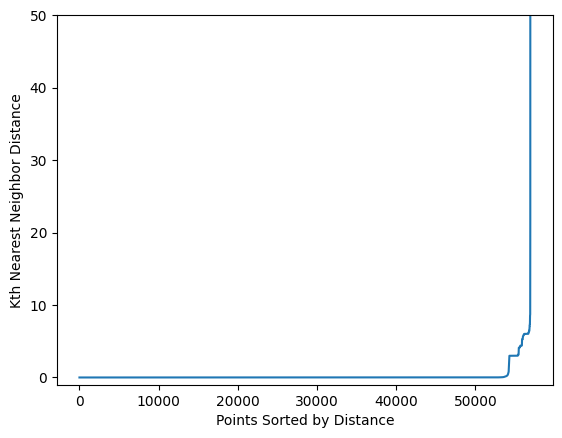

In [12]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.ylim(bottom=-1, top=50)
# plt.axhline(y=5.8, linestyle=':', color='red', linewidth=2)
None

In [163]:
from kneed import KneeLocator

# Find the elbow point automatically
i = np.arange(len(sorted_distances))
knee = KneeLocator(i, sorted_distances, S=1.0, curve='convex', direction='increasing')

optimal_eps = sorted_distances[knee.knee]
print(f"Estimated Epsilon: {optimal_eps}")

Estimated Epsilon: 9.33224738125786


In [164]:
"""
I initially tried 8.7 but it resulted in the following breakdown of clusters:

--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      -1            13               6       0.461538
       0         55377            5115       0.092367
       1          1557              56       0.035967

The positive class are clearly hidden in the large cluster. I hypothesize the mixed data (mostly binary and some numeric is causing issues for euclidian distance)
I will try use gower instead which handles mixed types
"""
eps = optimal_eps

In [165]:
# 1. Compute the custom distance matrix across your mixed data
# (Expects a pandas DataFrame or numpy array where columns are mixed)
distance_matrix = gower.gower_matrix(X_scaled)

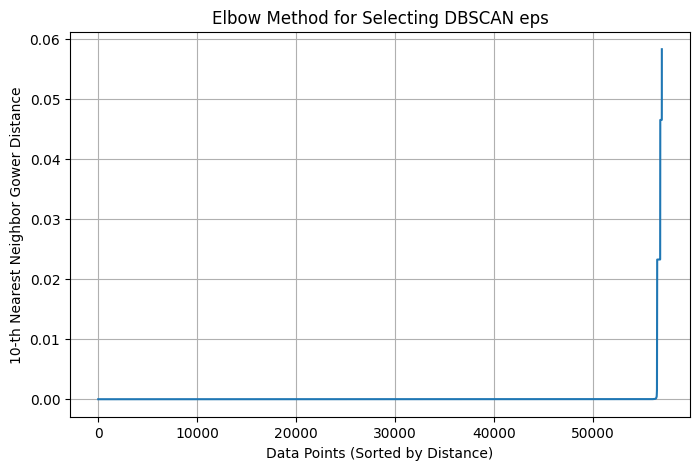

In [166]:

# Fit NearestNeighbors using the 'precomputed' Gower matrix
# We use k+1 because the closest neighbor to any point is always itself (distance 0)
neighbors = NearestNeighbors(n_neighbors=k+1, metric='precomputed')
neighbors_fit = neighbors.fit(distance_matrix)
distances, indices = neighbors_fit.kneighbors(distance_matrix)

# Grab the distance to the k-th nearest neighbor and sort
k_distances = np.sort(distances[:, k])

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Data Points (Sorted by Distance)')
plt.ylabel(f'{k}-th Nearest Neighbor Gower Distance')
plt.title('Elbow Method for Selecting DBSCAN eps')
plt.grid(True)
None

In [37]:
# clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
clustering = DBSCAN(eps=0.025, min_samples=min_samples, metric='precomputed').fit(distance_matrix)

In [38]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 75
Estimated number of noise points: 1212


In [39]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [40]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [41]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [42]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 56947
Global Positive Rate: 0.0010
Number of Clusters (excluding noise): 75


In [43]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
      65           470             361       0.768085
      13          2421            1206       0.498141
       2           347             162       0.466859
      26          3665            1663       0.453752
      45           299             132       0.441472
      54           193              79       0.409326
       5           356             144       0.404494
      61           278             112       0.402878
      29           282             111       0.393617
      46           290             114       0.393103


In [44]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
      10          7328             120       0.016376
       1          5197              90       0.017318
       7          4710              91       0.019321
      26          3665            1663       0.453752
      14          3282              52       0.015844
      13          2421            1206       0.498141
      12          1872              39       0.020833
      18          1855               0       0.000000
      16          1557              56       0.035967
      21          1193               0       0.000000


In [45]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 10.0 ---
                                      Cluster Mean   Global Mean  Difference
Amount Received                          -0.012511  9.981811e-19   -0.012511
Amount Paid                              -0.011658 -9.981811e-19   -0.011658
Amount_Received_USD                      -0.006843 -9.981811e-19   -0.006843
Amount_Paid_USD                          -0.006840  0.000000e+00   -0.006840
Receiving Currency_Australian Dollar     -0.172631 -6.787631e-17   -0.172631
Receiving Currency_Bitcoin               -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real           -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar       -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                  -0.553907  9.981811e-19   -0.553907
Receiving Currency_Mexican Peso          -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble                 -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee  

In [46]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 10.0 ---
|--- Payment Format_Cheque <= 0.33
|   |--- class: 0
|--- Payment Format_Cheque >  0.33
|   |--- Receiving Currency_US Dollar <= 0.28
|   |   |--- class: 0
|   |--- Receiving Currency_US Dollar >  0.28
|   |   |--- class: 1



In [48]:
# Profiling the cluster with many positive class
target_cluster_id = 65

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 65 ---
                                      Cluster Mean   Global Mean  Difference
Amount Received                           0.000419  9.981811e-19    0.000419
Amount Paid                               0.001306 -9.981811e-19    0.001306
Amount_Received_USD                       0.013846 -9.981811e-19    0.013846
Amount_Paid_USD                           0.013849  0.000000e+00    0.013849
Receiving Currency_Australian Dollar     -0.172631 -6.787631e-17   -0.172631
Receiving Currency_Bitcoin               -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real           -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar       -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                  -0.553907  9.981811e-19   -0.553907
Receiving Currency_Mexican Peso          -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble                 -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee    

In [55]:
X_scaled_df['Payment Currency_Saudi Riyal'].unique()

array([ 6.60260265, -0.15145543])

In [58]:
pd.set_option('display.max_columns', None)

In [59]:
cluster_features

,Amount Received,Amount Paid,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,Receiving Currency_Saudi Riyal,Receiving Currency_Shekel,Receiving Currency_Swiss Franc,Receiving Currency_UK Pound,Receiving Currency_US Dollar,Receiving Currency_Yen,Receiving Currency_Yuan,Payment Currency_Australian Dollar,Payment Currency_Bitcoin,Payment Currency_Brazil Real,Payment Currency_Canadian Dollar,Payment Currency_Euro,Payment Currency_Mexican Peso,Payment Currency_Ruble,Payment Currency_Rupee,Payment Currency_Saudi Riyal,Payment Currency_Shekel,Payment Currency_Swiss Franc,Payment Currency_UK Pound,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
634,-0.012986,-0.012134,-0.010279,-0.010276,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
1345,-0.013025,-0.012173,-0.010349,-0.010347,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
2037,-0.013027,-0.012175,-0.010353,-0.010350,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
2216,-0.012534,-0.011681,-0.009466,-0.009463,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
2454,-0.013016,-0.012163,-0.010332,-0.010330,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56880,-0.012934,-0.012081,-0.010185,-0.010182,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,2.875013,2.609505
56881,-0.012959,-0.012106,-0.010230,-0.010227,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.17133

In [70]:
cluster_features[cluster_features['Receiving Currency_US Dollar'] <= 0.28]

,Amount Received,Amount Paid,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,Receiving Currency_Saudi Riyal,Receiving Currency_Shekel,Receiving Currency_Swiss Franc,Receiving Currency_UK Pound,Receiving Currency_US Dollar,Receiving Currency_Yen,Receiving Currency_Yuan,Payment Currency_Australian Dollar,Payment Currency_Bitcoin,Payment Currency_Brazil Real,Payment Currency_Canadian Dollar,Payment Currency_Euro,Payment Currency_Mexican Peso,Payment Currency_Ruble,Payment Currency_Rupee,Payment Currency_Saudi Riyal,Payment Currency_Shekel,Payment Currency_Swiss Franc,Payment Currency_UK Pound,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
634,-0.012986,-0.012134,-0.010279,-0.010276,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
1345,-0.013025,-0.012173,-0.010349,-0.010347,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
2037,-0.013027,-0.012175,-0.010353,-0.010350,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
2216,-0.012534,-0.011681,-0.009466,-0.009463,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
2454,-0.013016,-0.012163,-0.010332,-0.010330,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,-0.347824,-0.383214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56880,-0.012934,-0.012081,-0.010185,-0.010182,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.171333,-0.16766,-0.120121,-0.169368,-0.552906,-0.144769,-0.17832,-0.195287,6.602603,-0.19024,-0.21899,-0.191672,-0.766316,-0.177427,-0.206175,2.09211,-0.16766,-0.310891,-0.719933,-0.558914,-0.30779,-0.183599,2.875013,2.609505
56881,-0.012959,-0.012106,-0.010230,-0.010227,-0.172631,-0.168984,-0.121169,-0.170244,-0.553907,-0.145274,-0.179783,-0.196928,6.573698,-0.191968,-0.220439,-0.192164,-0.760438,-0.177743,-0.202632,-0.17133

In [56]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 65 ---
|--- Payment Currency_Saudi Riyal <= 3.23
|   |--- class: 0
|--- Payment Currency_Saudi Riyal >  3.23
|   |--- Payment Format_ACH <= 0.81
|   |   |--- class: 0
|   |--- Payment Format_ACH >  0.81
|   |   |--- Receiving Currency_US Dollar <= 0.28
|   |   |   |--- class: 1
|   |   |--- Receiving Currency_US Dollar >  0.28
|   |   |   |--- class: 0



In [ ]:
# Profiling the cluster with many positive class
target_cluster_id = 13

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 13 ---
                                      Cluster Mean   Global Mean  Difference
Amount Received                          -0.011887  9.981811e-19   -0.011887
Amount Paid                              -0.011032 -9.981811e-19   -0.011032
Amount_Received_USD                      -0.002663 -9.981811e-19   -0.002663
Amount_Paid_USD                          -0.002660  0.000000e+00   -0.002660
Receiving Currency_Australian Dollar     -0.172631 -6.787631e-17   -0.172631
Receiving Currency_Bitcoin               -0.168984 -6.388359e-17   -0.168984
Receiving Currency_Brazil Real           -0.121169  1.073045e-17   -0.121169
Receiving Currency_Canadian Dollar       -0.170244  2.944634e-17   -0.170244
Receiving Currency_Euro                   1.805356  9.981811e-19    1.805356
Receiving Currency_Mexican Peso          -0.145274  4.491815e-17   -0.145274
Receiving Currency_Ruble                 -0.179783 -1.696908e-17   -0.179783
Receiving Currency_Rupee    

In [ ]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 13 ---
|--- Payment Format_ACH <= 0.81
|   |--- class: 0
|--- Payment Format_ACH >  0.81
|   |--- Payment Currency_Euro <= 0.63
|   |   |--- class: 0
|   |--- Payment Currency_Euro >  0.63
|   |   |--- Receiving Currency_Euro <= 0.63
|   |   |   |--- class: 0
|   |   |--- Receiving Currency_Euro >  0.63
|   |   |   |--- class: 1



## PPP

### Import Dataset

In [3]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


In [4]:
df.dropna(inplace=True)

In [5]:
X = df.drop(columns='Fraud')
y = df['Fraud']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 968433, 1: 95})
Resampled dataset shape: Counter({0: 9500, 1: 95})


### Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### DBScan

In [7]:
min_samples = 2 * len(X.columns) # 2*D to avoid clustering marking sparse regions as valid clusters. With a value of 3 I found 1800 clusters
min_samples

82

In [126]:
# In this case 2xD did not work well with 95 positive class it could be a bit too sparse to create its own cluster
# Dense regions containing less than min_samples cannot form their own cluster forcing it to merge into cluster 0 or become noise
min_samples = 10

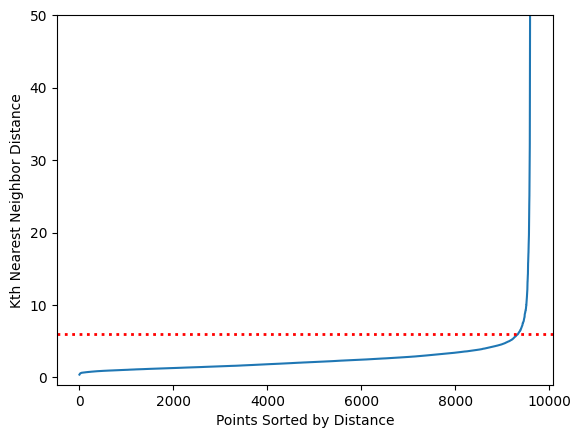

In [127]:
# 1. Set k to your min_samples value
k = min_samples

# 2. Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# 3. Sort distances by the k-th neighbor column (index k-1)
sorted_distances = np.sort(distances[:, k-1])

# 4. Plot to find the Epsilon elbow
plt.plot(sorted_distances)
plt.ylabel("Kth Nearest Neighbor Distance")
plt.xlabel("Points Sorted by Distance")
plt.ylim(bottom=-1, top=50)
plt.axhline(y=6, linestyle=':', color='red', linewidth=2)
None

In [128]:
eps = 6.0

I initially tried 6.0 but it resulted in the following breakdown of clusters:


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---

 cluster  cluster_size  positive_count  positive_rate

      -1          1246               3       0.002408
      
       0         93849              92       0.000980


The positive class are clearly hidden in the large cluster. I hypothesize the mixed data (mostly binary and some numeric is causing issues for euclidian distance)

I will try use gower instead which handles mixed types

In [129]:
# 1. Compute the custom distance matrix across your mixed data
# (Expects a pandas DataFrame or numpy array where columns are mixed)
distance_matrix = gower.gower_matrix(X_scaled)

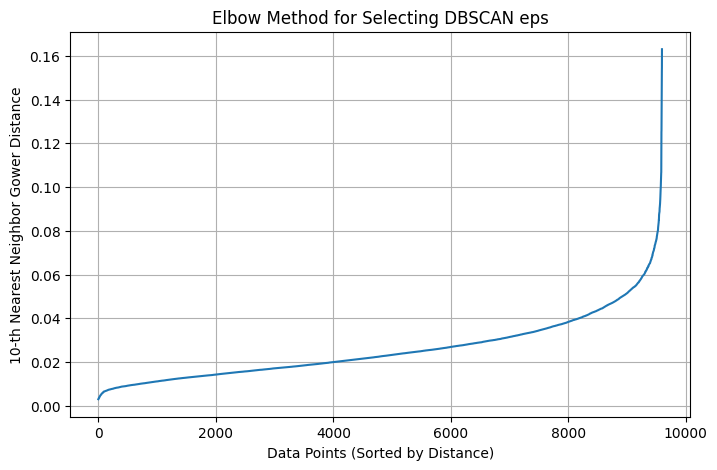

In [130]:
k = min_samples

# Fit NearestNeighbors using the 'precomputed' Gower matrix
# We use k+1 because the closest neighbor to any point is always itself (distance 0)
neighbors = NearestNeighbors(n_neighbors=k+1, metric='precomputed')
neighbors_fit = neighbors.fit(distance_matrix)
distances, indices = neighbors_fit.kneighbors(distance_matrix)

# Grab the distance to the k-th nearest neighbor and sort
k_distances = np.sort(distances[:, k])

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Data Points (Sorted by Distance)')
plt.ylabel(f'{k}-th Nearest Neighbor Gower Distance')
plt.title('Elbow Method for Selecting DBSCAN eps')
plt.grid(True)
None

In [138]:
# clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
# clustering = DBSCAN(eps=0.05, min_samples=min_samples, metric='precomputed').fit(distance_matrix)
clustering = DBSCAN(eps=0.03, min_samples=min_samples, metric='precomputed').fit(distance_matrix)

In [139]:
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 7
Estimated number of noise points: 1503


In [140]:
# Convert X to pandas df for easier aggregation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns).copy()

In [141]:
# Combine cluster labels and target variable into a single summary DataFrame
summary_df = pd.DataFrame({"cluster": labels, "target": y_resampled})

In [142]:
# --- 3. Aggregate Cluster Statistics ---
cluster_stats = (
    summary_df.groupby("cluster")
    .agg(
        cluster_size=("target", "count"),
        positive_count=("target", "sum"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

In [143]:
# Global metrics for context
global_pos_rate = y.mean()
print(f"Total Data Points: {len(X_scaled_df)}")
print(f"Global Positive Rate: {global_pos_rate:.4f}")
print(
    f"Number of Clusters (excluding noise): {len(set(labels)) - (1 if -1 in labels else 0)}"
)

Total Data Points: 9595
Global Positive Rate: 0.0001
Number of Clusters (excluding noise): 7


In [144]:
# --- 4. Identify Target-Rich Clusters ---
# Sort by highest concentration of your positive target class
high_purity_clusters = cluster_stats.sort_values(
    by="positive_rate", ascending=False
).head(10)
print("\n--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---")
print(high_purity_clusters.to_string(index=False))


--- TOP 10 CLUSTERS BY POSITIVE CLASS RATE ---
 cluster  cluster_size  positive_count  positive_rate
       2           110              24       0.218182
      -1          1503              59       0.039255
       3            39               1       0.025641
       1           434               6       0.013825
       0          7400               5       0.000676
       4            69               0       0.000000
       5             9               0       0.000000
       6            31               0       0.000000


In [145]:
# --- 5. Identify Popular Clusters ---
# Sort by size to find the largest groups (excluding noise cluster -1)
popular_clusters = (
    cluster_stats[cluster_stats["cluster"] != -1]
    .sort_values(by="cluster_size", ascending=False)
    .head(10)
)
print("\n--- TOP 10 LARGEST VALID CLUSTERS ---")
print(popular_clusters.to_string(index=False))


--- TOP 10 LARGEST VALID CLUSTERS ---
 cluster  cluster_size  positive_count  positive_rate
       0          7400               5       0.000676
       1           434               6       0.013825
       2           110              24       0.218182
       4            69               0       0.000000
       3            39               1       0.025641
       6            31               0       0.000000
       5             9               0       0.000000


In [146]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = popular_clusters.iloc[0]["cluster"]

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 0.0 ---
                               Cluster Mean   Global Mean  Difference
ProcessingMethod                  -0.113093 -7.183183e-17   -0.113093
BorrowerState                      0.011235 -8.886413e-18    0.011235
LoanStatus                         0.405340 -5.331848e-17    0.405340
Term                              -0.149798  1.199666e-16   -0.149798
InitialApprovalAmount             -0.142448 -9.923161e-17   -0.142448
CurrentApprovalAmount             -0.143727 -1.658797e-16   -0.143727
ServicingLenderState               0.000995 -4.146993e-17    0.000995
RuralUrbanIndicator                0.034252  1.077478e-16    0.034252
HubzoneIndicator                  -0.050062 -4.739420e-17   -0.050062
LMIIndicator                      -0.044387 -1.999443e-17   -0.044387
BusinessAgeDescription            -0.006948 -1.303341e-16   -0.006948
ProjectState                       0.011235 -8.886413e-18    0.011235
JobsReported                      -0.1340

In [147]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 0.0 ---
|--- LoanStatus <= -1.03
|   |--- class: 0
|--- LoanStatus >  -1.03
|   |--- TOTAL_PROCEED <= 2.05
|   |   |--- ForgivenPercentage <= -2.22
|   |   |   |--- class: 0
|   |   |--- ForgivenPercentage >  -2.22
|   |   |   |--- class: 1
|   |--- TOTAL_PROCEED >  2.05
|   |   |--- JobsReported <= 2.55
|   |   |   |--- class: 0
|   |   |--- JobsReported >  2.55
|   |   |   |--- class: 0



In [149]:
# --- 6. Profile a Cluster of Interest ---
# Dynamically pick the most popular cluster to profile its characteristics
target_cluster_id = 2

# Filter the original X data using the cluster labels
cluster_mask = labels == target_cluster_id
cluster_features = X_scaled_df[cluster_mask]

print(f"\n--- CHARACTERISTICS FOR POPULAR CLUSTER {target_cluster_id} ---")
profile_df = pd.DataFrame(
    {
        "Cluster Mean": cluster_features.mean(),
        "Global Mean": X_scaled_df.mean(),
        "Difference": cluster_features.mean() - X_scaled_df.mean(),
    }
)
print(profile_df)



--- CHARACTERISTICS FOR POPULAR CLUSTER 2 ---
                               Cluster Mean   Global Mean  Difference
ProcessingMethod                  -0.651001 -7.183183e-17   -0.651001
BorrowerState                     -0.127090 -8.886413e-18   -0.127090
LoanStatus                        -2.467065 -5.331848e-17   -2.467065
Term                              -0.960266  1.199666e-16   -0.960266
InitialApprovalAmount             -0.187846 -9.923161e-17   -0.187846
CurrentApprovalAmount             -0.191846 -1.658797e-16   -0.191846
ServicingLenderState               0.219763 -4.146993e-17    0.219763
RuralUrbanIndicator                0.422271  1.077478e-16    0.422271
HubzoneIndicator                  -0.539217 -4.739420e-17   -0.539217
LMIIndicator                      -0.557486 -1.999443e-17   -0.557486
BusinessAgeDescription             0.339694 -1.303341e-16    0.339694
ProjectState                      -0.127090 -8.886413e-18   -0.127090
JobsReported                      -0.133237

In [151]:
# --- 7. Generate Explanatory Rules (Decision Tree) ---
# Train a small tree to isolate exactly what makes this cluster unique from the rest
from sklearn.tree import DecisionTreeClassifier, export_text


is_target_cluster = (labels == target_cluster_id).astype(int)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_scaled_df, is_target_cluster)

print(
    f"\n--- DECISION TREE RULES DEFINING CLUSTER {target_cluster_id} ---"
)
tree_rules = export_text(dt, feature_names=list(X_scaled_df.columns))
print(tree_rules)


--- DECISION TREE RULES DEFINING CLUSTER 2 ---
|--- LoanStatusDate_int <= -2.24
|   |--- ForgivenessDate_int <= -1.31
|   |   |--- HubzoneIndicator <= 0.53
|   |   |   |--- class: 1
|   |   |--- HubzoneIndicator >  0.53
|   |   |   |--- class: 0
|   |--- ForgivenessDate_int >  -1.31
|   |   |--- class: 0
|--- LoanStatusDate_int >  -2.24
|   |--- LoanStatusDate_int <= -1.92
|   |   |--- CurrentApprovalAmount <= -0.50
|   |   |   |--- class: 1
|   |   |--- CurrentApprovalAmount >  -0.50
|   |   |   |--- class: 0
|   |--- LoanStatusDate_int >  -1.92
|   |   |--- class: 0

